In [1]:
import json
import pandas as pd
import glob
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import unicodedata
from underthesea import word_tokenize
from nltk.util import ngrams
from collections import Counter
from wordcloud import WordCloud
from pyvi import ViTokenizer, ViPosTagger

In [2]:
files = glob.glob("../data/parsed/*.json")
print(f"Số lượng văn bản: {len(files)}")
prs = []
chs = []
sec = []
art = []
cla = []
pts = []

print("Danh sách các văn bản:")
for f in files:
    with open(f, "r", encoding="utf-8") as file:
        data = json.load(file)
        nodes = data["nodes"]
        print(f"{nodes["document"]["doc_identity"]} - {nodes["document"]["doc_name"]}")
        for pa in nodes["parts"]:
            prs.append(pa)
        for ch in nodes["chapters"]:
            chs.append(ch)
        for se in nodes["sections"]:
            sec.append(se)
        for ar in nodes["articles"]:
            art.append(ar)
        for cl in nodes["clauses"]:
            cla.append(cl)
        for pt in nodes["points"]:
            pts.append(pt)

parts = pd.DataFrame(prs)
chapters = pd.DataFrame(chs)
sections = pd.DataFrame(sec)
articles = pd.DataFrame(art)
clauses = pd.DataFrame(cla)
points = pd.DataFrame(pts)

Số lượng văn bản: 12
Danh sách các văn bản:
56/2024/QH15 - Luật sửa đổi, bổ sung một số điều của Luật Chứng khoán, Luật Kế toán, Luật Kiểm toán độc lập, Luật Ngân sách Nhà nước, Luật Quản lý, sử dụng tài sản công, Luật Quản lý thuế, Luật Thuế thu nhập cá nhân, Luật Dự trữ quốc gia, Luật Xử lý vi phạm hành chính của Quốc hội, số 56/2024/QH15
118/2025/QH15 - Luật sửa đổi, bổ sung một số điều của 10 Luật có liên quan đến an ninh, trật tự của Quốc hội, số 118/2025/QH15
88/2025/QH15 - Luật sửa đổi, bổ sung một số điều của Luật Xử lý vi phạm hành chính của Quốc hội, số 88/2025/QH15
15/2012/QH13 - Luật Xử lý vi phạm hành chính của Quốc hội, số 15/2012/QH13
119/2024/NĐ-CP - Nghị định 119/2024/NĐ-CP của Chính phủ quy định về thanh toán điện tử giao thông đường bộ
36/2024/QH15 - Luật Trật tự, an toàn giao thông đường bộ của Quốc hội, số 36/2024/QH15
35/2024/QH15 - Luật Đường bộ của Quốc hội, số 35/2024/QH15
44/2019/QH14 - Luật Phòng, chống tác hại của rượu, bia của Quốc hội, số 44/2019/QH14
123/

In [3]:
print(parts.isnull().sum())
print(chapters.isnull().sum())
print(sections.isnull().sum())
print(articles.isnull().sum())
print(clauses.isnull().sum())
print(points.isnull().sum())

number          0
title           0
doc_identity    0
order           0
content         0
dtype: int64
number           0
title            0
doc_identity     0
parent_part     37
order            0
content          0
dtype: int64
number            0
title             0
doc_identity      0
parent_chapter    0
order             0
content           0
dtype: int64
number              0
title               0
doc_identity        0
parent_chapter     56
parent_section    340
order               0
content             0
dtype: int64
number            0
doc_identity      0
parent_article    0
order             0
content           0
dtype: int64
letter            0
doc_identity      0
parent_article    0
parent_clause     0
order             0
content           0
dtype: int64


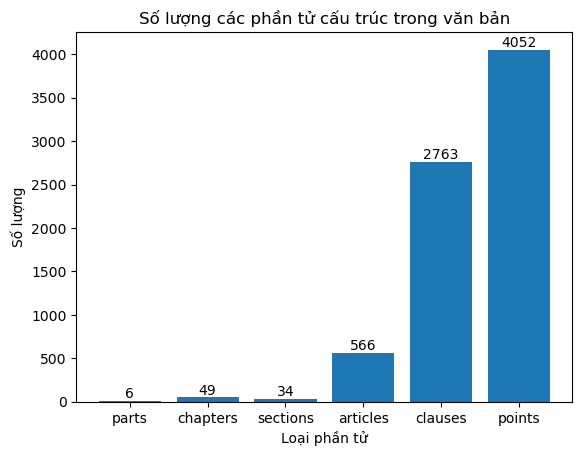

In [4]:
counts = {
    "parts": len(parts),
    "chapters": len(chapters),
    "sections": len(sections),
    "articles": len(articles),
    "clauses": len(clauses),
    "points": len(points)
}
labels = list(counts.keys())
values = list(counts.values())
bars = plt.bar(labels, values)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(int(height)),
             ha='center', va='bottom')
plt.title("Số lượng các phần tử cấu trúc trong văn bản")
plt.xlabel("Loại phần tử")
plt.ylabel("Số lượng")
plt.show()

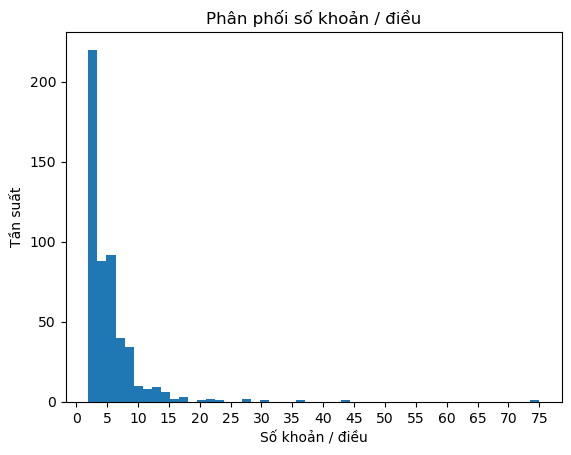

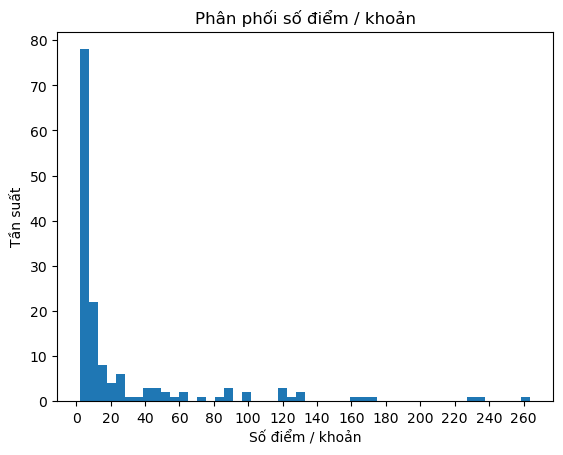

In [5]:
clause_count = clauses.groupby(["doc_identity", "parent_article"]).size()
plt.hist(clause_count, bins=50)
plt.gca().xaxis.set_major_locator(MultipleLocator(5))
plt.title("Phân phối số khoản / điều")
plt.xlabel("Số khoản / điều")
plt.ylabel("Tần suất")
plt.show()
point_count = points.groupby(["doc_identity", "parent_clause"]).size()
plt.hist(point_count, bins=50)
plt.gca().xaxis.set_major_locator(MultipleLocator(20))
plt.title("Phân phối số điểm / khoản")
plt.xlabel("Số điểm / khoản")
plt.ylabel("Tần suất")
plt.show()

In [6]:
text_cols = [
    "content",
    "title",
]
texts = []
for col in text_cols:
    for df in [parts, chapters, sections, articles, clauses, points]:
        if col in df:
            texts.extend(
                [x for x in df[col].dropna().astype(str) if x.strip() != ""]
            )
texts = [
    unicodedata.normalize("NFC", t).lower()
    for t in texts
]

In [7]:
with open("vietnamese-stopwords.txt", encoding="utf-8") as f:
    stopwords = set(f.read().splitlines())

In [8]:
def has_punctuation(s):
    return any(unicodedata.category(c).startswith("P") and c != ' ' and c != '_' for c in s)
tokens = []
for text in texts:
    tk = word_tokenize(text)
    # tk = [t for t in tk if not has_punctuation(t)]
    tk = [t for t in tk if t not in stopwords]
    tokens.extend(tk)

In [9]:
tokens = [t for t in tokens if len(t) > 1]
print(f"Số lượng token: {len(tokens)}")

Số lượng token: 138434


In [10]:
print(f"Số lượng token riêng biệt: {len(set(tokens))}")

Số lượng token riêng biệt: 3344


In [11]:
print(f"Tỷ lệ: {len(set(tokens))/len(tokens)}")

Tỷ lệ: 0.02415591545429591


In [12]:
df_text = pd.DataFrame({
    "content": texts
})
df_text["tokens"] = df_text["content"].apply(lambda x: word_tokenize(x))
df_text["length"] = df_text["tokens"].apply(len)
df_text.head()

,content,tokens,length
0,\nnhững quy định chung,"[những, quy định, chung]",3
1,\nkết cấu hạ tầng đường bộ,"[kết cấu hạ tầng, đường bộ]",2
2,\nđường bộ cao tốc,"[đường bộ, cao tốc]",2
3,\nvận tải đường bộ,"[vận tải, đường bộ]",2
4,\nquản lý nhà nước về hoạt động đường bộ,"[quản lý nhà nước, về, hoạt động, đường bộ]",4


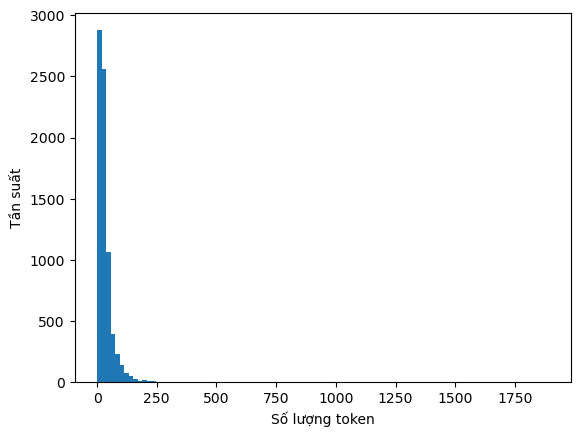

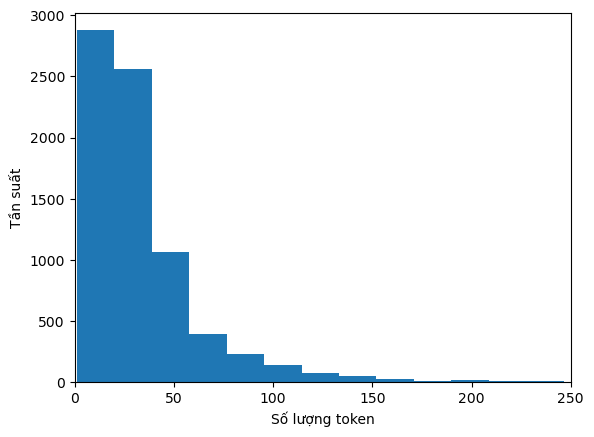

In [13]:
plt.hist(df_text["length"], bins=100)
plt.xlabel("Số lượng token")
plt.ylabel("Tần suất")
plt.show()
plt.hist(df_text["length"], bins=100)
plt.xlim(0, 250)
plt.xlabel("Số lượng token")
plt.ylabel("Tần suất")
plt.show()

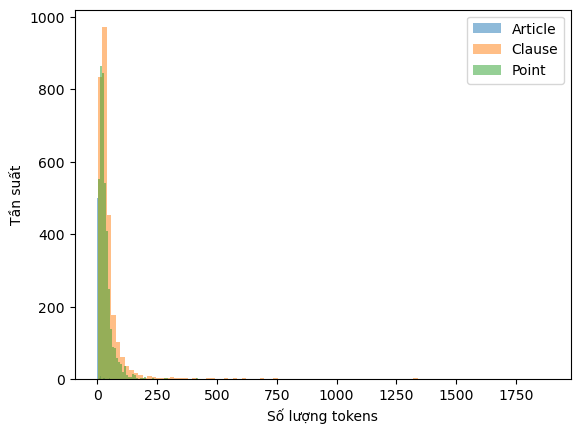

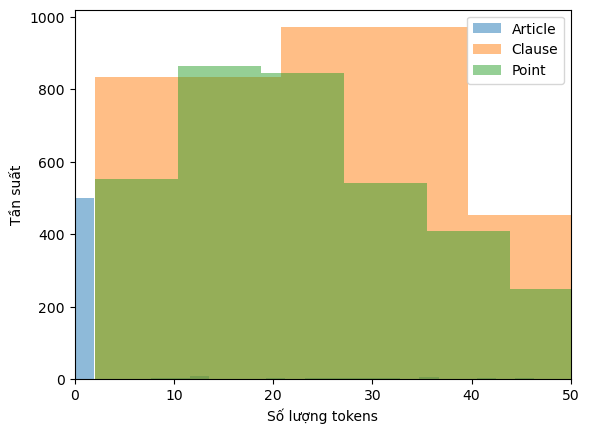

In [14]:
def word_count(text):
    tokens = word_tokenize(text)
    return len(tokens)
article_texts = articles["content"].dropna().tolist()
clause_texts = clauses["content"].dropna().tolist()
point_texts = points["content"].dropna().tolist()
article_wc = [word_count(t) for t in article_texts]
clause_wc = [word_count(t) for t in clause_texts]
point_wc = [word_count(t) for t in point_texts]
plt.hist(article_wc, bins=100, alpha=0.5, label=f'Article')
plt.hist(clause_wc, bins=100, alpha=0.5, label=f'Clause')
plt.hist(point_wc, bins=100, alpha=0.5, label=f'Point')
plt.xlabel("Số lượng tokens")
plt.ylabel("Tần suất")
plt.legend()
plt.show()
plt.hist(article_wc, bins=100, alpha=0.5, label=f'Article')
plt.hist(clause_wc, bins=100, alpha=0.5, label=f'Clause')
plt.hist(point_wc, bins=100, alpha=0.5, label=f'Point')
plt.xlabel("Số lượng tokens")
plt.ylabel("Tần suất")
plt.xlim(0, 50)
plt.legend()
plt.show()

In [15]:
all_texts = " ".join(texts)
vit = ViTokenizer.tokenize(all_texts)
words, pos_tags = ViPosTagger.postagging(vit)
pos_data = [(w, t) for w, t in zip(words, pos_tags)]

In [16]:
pos_data = [(w, t) for w, t in pos_data if not has_punctuation(w)]
pos_data = [(w, t) for w, t in pos_data if w.lower() not in stopwords]
pos_data = [(w, t) for w, t in pos_data if len(w) > 1]

In [17]:
LEGAL_POS_FIX = {
    "xử_phạt": "V",
    "lái_xe": "V"
}
pos_data = [
    (w, LEGAL_POS_FIX.get(w.lower(), t)) if t == 'A' else (w, t)
    for w, t in pos_data
]

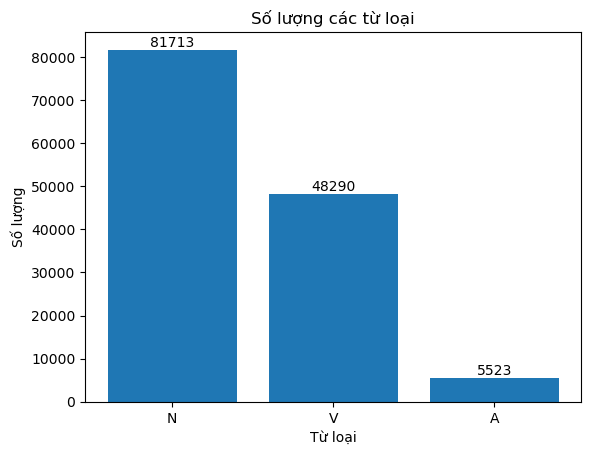

In [31]:
tags = [t for w, t in pos_data]
pos_counts = Counter(tags)
df_pos = pd.DataFrame(pos_counts.items(), columns=['POS_Tag', 'Count'])
target_tags = ['N', 'V', 'A']
df_filtered = df_pos[df_pos['POS_Tag'].isin(target_tags)].copy()
df_filtered = df_filtered.sort_values(by='Count', ascending=False)
bars = plt.bar(df_filtered['POS_Tag'], df_filtered['Count'])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(int(height)),
             ha='center', va='bottom')
plt.title("Số lượng các từ loại")
plt.xlabel("Từ loại")
plt.ylabel("Số lượng")
plt.show()

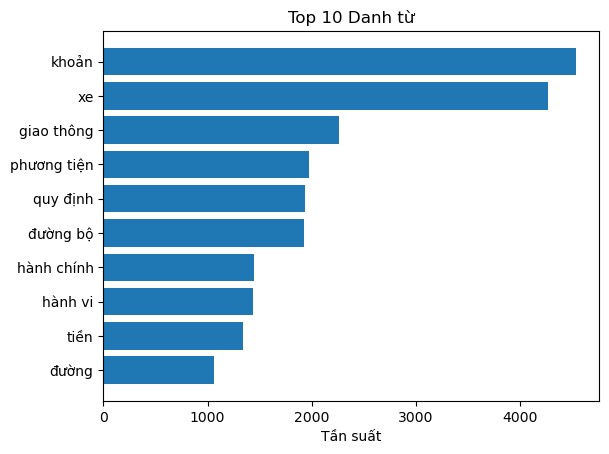

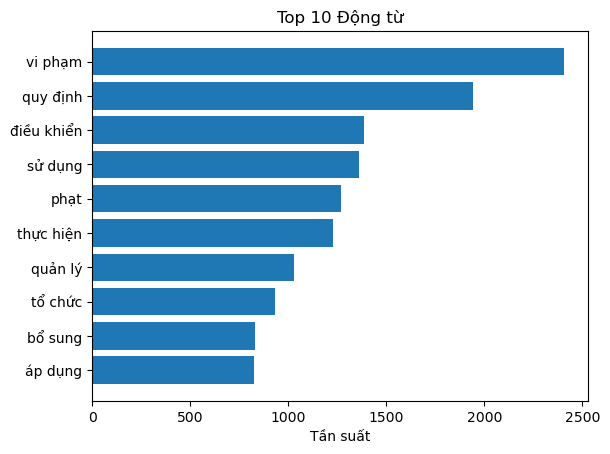

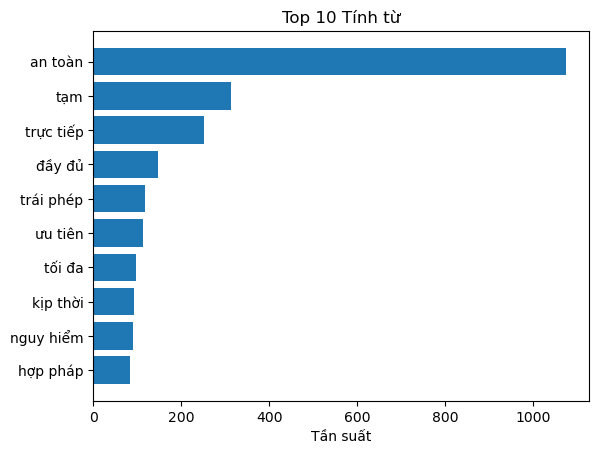

In [19]:
pos_word_freq = {}
for w, t in pos_data:
    if t not in pos_word_freq:
        pos_word_freq[t] = Counter()
    pos_word_freq[t][w] += 1

target_tags = ['N', 'V', 'A'] 
tag_names = {'N': 'Danh từ', 'V': 'Động từ', 'A': 'Tính từ'}

for tag in target_tags:
    if tag in pos_word_freq:
        counter = pos_word_freq[tag]

        top_words = counter.most_common(10)

        words = [w.replace('_', ' ') for w, _ in top_words]
        counts = [c for _, c in top_words]

        plt.figure()
        plt.barh(words, counts)
        plt.xlabel("Tần suất")
        plt.title(f"Top 10 {tag_names.get(tag, tag)}")
        plt.gca().invert_yaxis()
        plt.show()

In [20]:
word_freq = Counter(tokens)

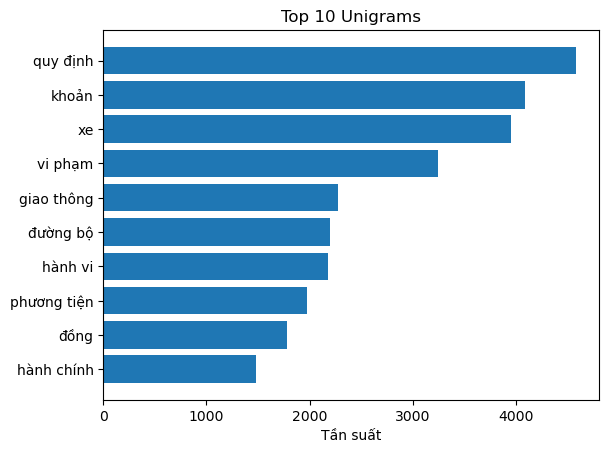

In [21]:
top_words = word_freq.most_common(10)
words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]
plt.barh(words, counts)
plt.xlabel("Tần suất")
plt.title("Top 10 Unigrams")
plt.gca().invert_yaxis()
plt.show()

In [22]:
redundant = ["điều", "khoản", "điểm", "đồng"]

In [23]:
bigrams = list(ngrams(tokens, 2))
bigrams = [bg for bg in bigrams if bg[0] != bg[1]]
# bigrams = [
#     (w1, w2)
#     for w1, w2 in bigrams
#     if w1 not in redundant and w2 not in redundant
# ]

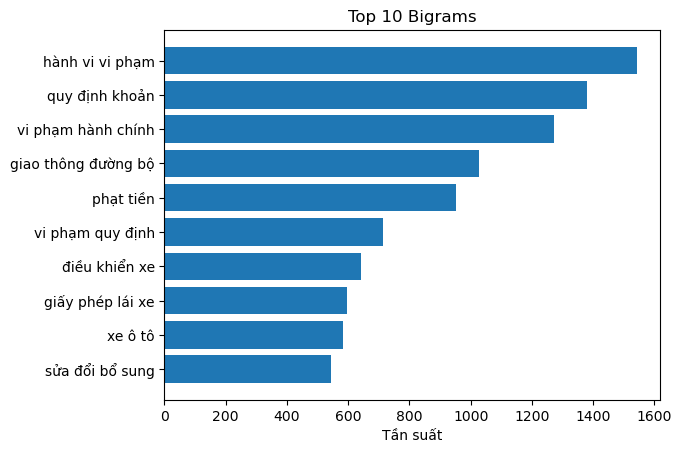

In [24]:
bi = Counter(bigrams).most_common(10)
words = [" ".join(x[0]) for x in bi]
counts = [x[1] for x in bi]
plt.barh(words, counts)
plt.xlabel("Tần suất")
plt.title("Top 10 Bigrams")
plt.gca().invert_yaxis()
plt.show()

In [25]:
word_freqs = {" ".join(k): v for k, v in Counter(bigrams).items()}

In [26]:
trigrams = list(ngrams(tokens, 3))
trigrams = [tg for tg in trigrams if tg[0] != tg[1] and tg[0] != tg[2] and tg[1] != tg[2]]
# trigrams = [
#     (w1, w2, w3)
#     for w1, w2, w3 in trigrams
#     if w1 not in redundant and w2 not in redundant and w3 not in redundant
# ]

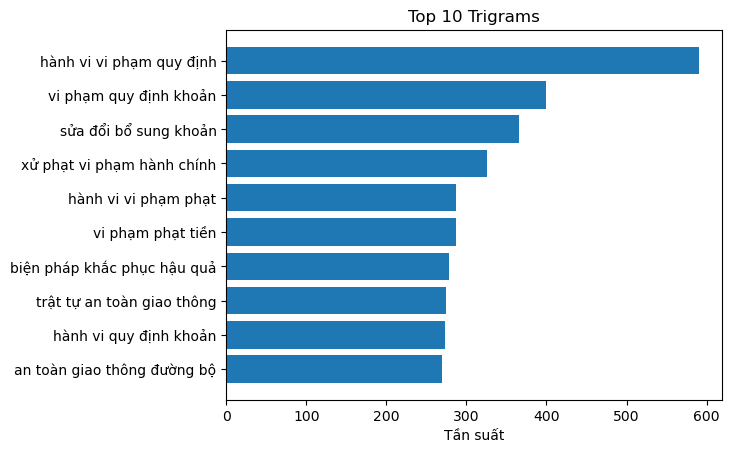

In [27]:
tri = Counter(trigrams).most_common(10)
words = [" ".join(x[0]) for x in tri]
counts = [x[1] for x in tri]
plt.barh(words, counts)
plt.xlabel("Tần suất")
plt.title("Top 10 Trigrams")
plt.gca().invert_yaxis()
plt.show()

In [28]:
quadgrams = list(ngrams(tokens, 4))
quadgrams = [qg for qg in quadgrams if qg[0] != qg[1] and qg[0] != qg[2] and qg[0] != qg[3] and qg[1] != qg[2] and qg[1] != qg[3] and qg[2] != qg[3]]
# quadgrams = [
#     (w1, w2, w3, w4)
#     for w1, w2, w3, w4 in trigrams
#     if w1 not in redundant and w2 not in redundant and w3 not in redundant and w4 not in redundant
# ]

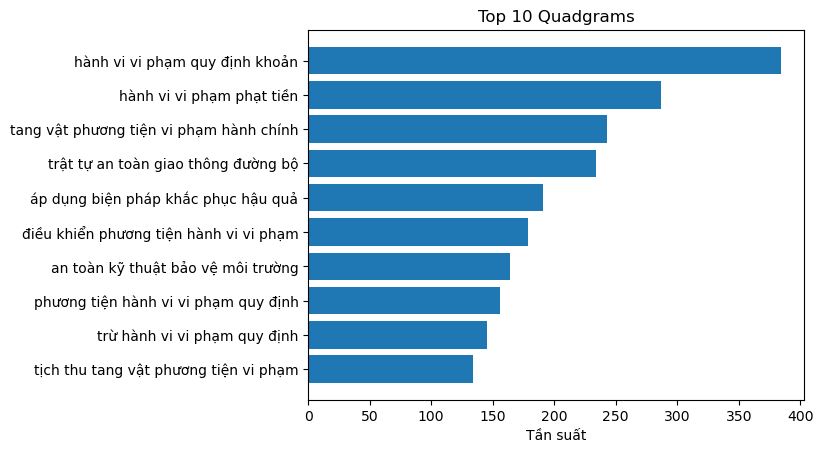

In [29]:
quad = Counter(quadgrams).most_common(10)
words = [" ".join(x[0]) for x in quad]
counts = [x[1] for x in quad]
plt.barh(words, counts)
plt.xlabel("Tần suất")
plt.title("Top 10 Quadgrams")
plt.gca().invert_yaxis()
plt.show()

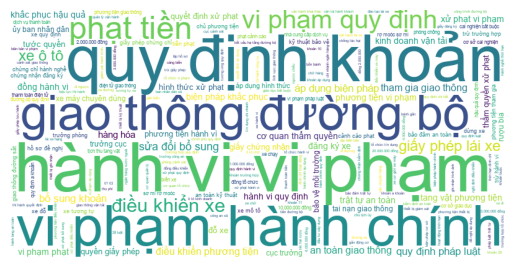

In [30]:
wordcloud = WordCloud(
    font_path="arial.ttf",
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(word_freqs)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()